# 05 — Classification (`case_type_grouped`)

Final W8 comparison of all four §3 models on the **5-class** task. Produces
the figures for slide 9:

- Macro-F1 / per-class precision-recall table across NB, LR, Bi-LSTM, BERT.
- One confusion matrix per model.
- Best-model per-class report for the slide bullet.

This notebook assumes you've already trained all four models — locally for
NB/LR (`python -m src.classify.train --task case_type --model {nb,lr}`) and on
Colab for Bi-LSTM/BERT (see `06_classification_colab.ipynb`). The Colab zip
should be unpacked under the project root so `models/` and `results/` line up.

In [1]:
import json, sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from src.utils import RESULTS_DIR

TASK = 'case_type'
TAG = 'casetype'
MODELS = ['nb', 'lr', 'lstm', 'bert']


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/xiongfeng/miniconda3/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/xiongfeng/miniconda3/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/xiongfeng/miniconda3/lib/python3.10/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/xiongfeng/miniconda3/lib/python3.10/site-packages/traitlets/config/application.py", line 992, in launch_instance
    ap

AttributeError: _ARRAY_API not found

## 1. Headline metrics across all 4 models

Filtered + pivoted from `results/classification_metrics.csv`.

In [2]:
metrics = pd.read_csv(RESULTS_DIR / 'classification_metrics.csv')
metrics = metrics.drop_duplicates(
    subset=['task', 'model', 'input_source', 'split'], keep='last'
)
test = metrics[(metrics.task == TASK) & (metrics.split == 'test')]
test = test.set_index('model').reindex(MODELS)
display(test[['accuracy', 'f1_macro', 'f1_weighted', 'auc_roc', 'train_seconds', 'notes']])

,accuracy,f1_macro,f1_weighted,auc_roc,train_seconds,notes
model,,,,,,
nb,0.7756,0.6840,0.7644,0.9442,1.0,ComplementNB(alpha=0.3) | text=long_ref | 5-class
lr,0.7596,0.6298,0.7404,0.9710,17.2,LR L2 saga class_weight=balanced | text=long_r...
lstm,0.7436,0.6364,0.7401,0.9141,29.8,BiLSTM(128)+Word2Vec(300) | text=long_ref | 5-...
bert,0.8974,0.8539,0.8965,0.9717,80.6,BERT=nlpaueb/legal-bert-base-uncased | text=lo...


## 2. Bar chart: Macro-F1 by model (slide 9 headline)

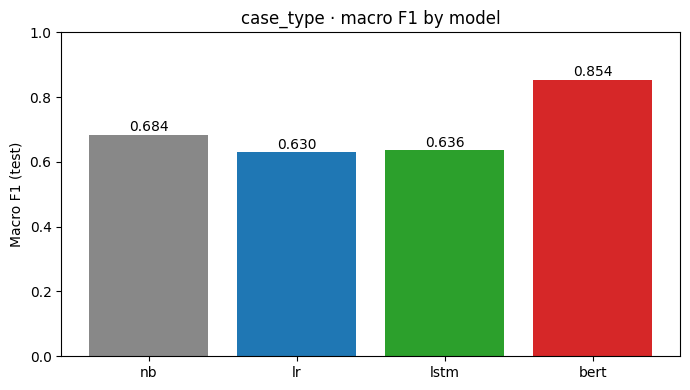

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(test.index, test['f1_macro'], color=['#888', '#1f77b4', '#2ca02c', '#d62728'])
for i, v in enumerate(test['f1_macro']):
    if not pd.isna(v):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center')
ax.set_ylabel('Macro F1 (test)')
ax.set_title('case_type · macro F1 by model')
ax.set_ylim(0, 1)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'case_type_macroF1_by_model.png', dpi=150)
plt.show()

## 3. Per-class precision/recall — load from JSON reports

In [4]:
rows = []
for model in MODELS:
    p = RESULTS_DIR / 'classification_reports' / f'{model}_{TAG}_test.json'
    if not p.exists():
        print(f'⚠️ missing {p}; train {model} first.')
        continue
    report = json.loads(p.read_text())
    for cls_name, vals in report.items():
        if cls_name in {'accuracy', 'macro avg', 'weighted avg'}:
            continue
        rows.append({
            'model': model, 'class': cls_name,
            'precision': vals['precision'], 'recall': vals['recall'],
            'f1': vals['f1-score'], 'support': vals['support'],
        })
per_class = pd.DataFrame(rows)
per_class_f1 = per_class.pivot(index='class', columns='model', values='f1')
display(per_class_f1.round(3))

model,bert,lr,lstm,nb
class,,,,
Civil Rights & Equality,0.925,0.838,0.739,0.833
Criminal Justice,0.958,0.775,0.870,0.781
Healthcare & Disability,0.645,0.000,0.154,0.222
Immigration & Education,0.904,0.758,0.727,0.775
Speech & Voting,0.837,0.779,0.692,0.809


## 4. Confusion matrices side-by-side (one per model)

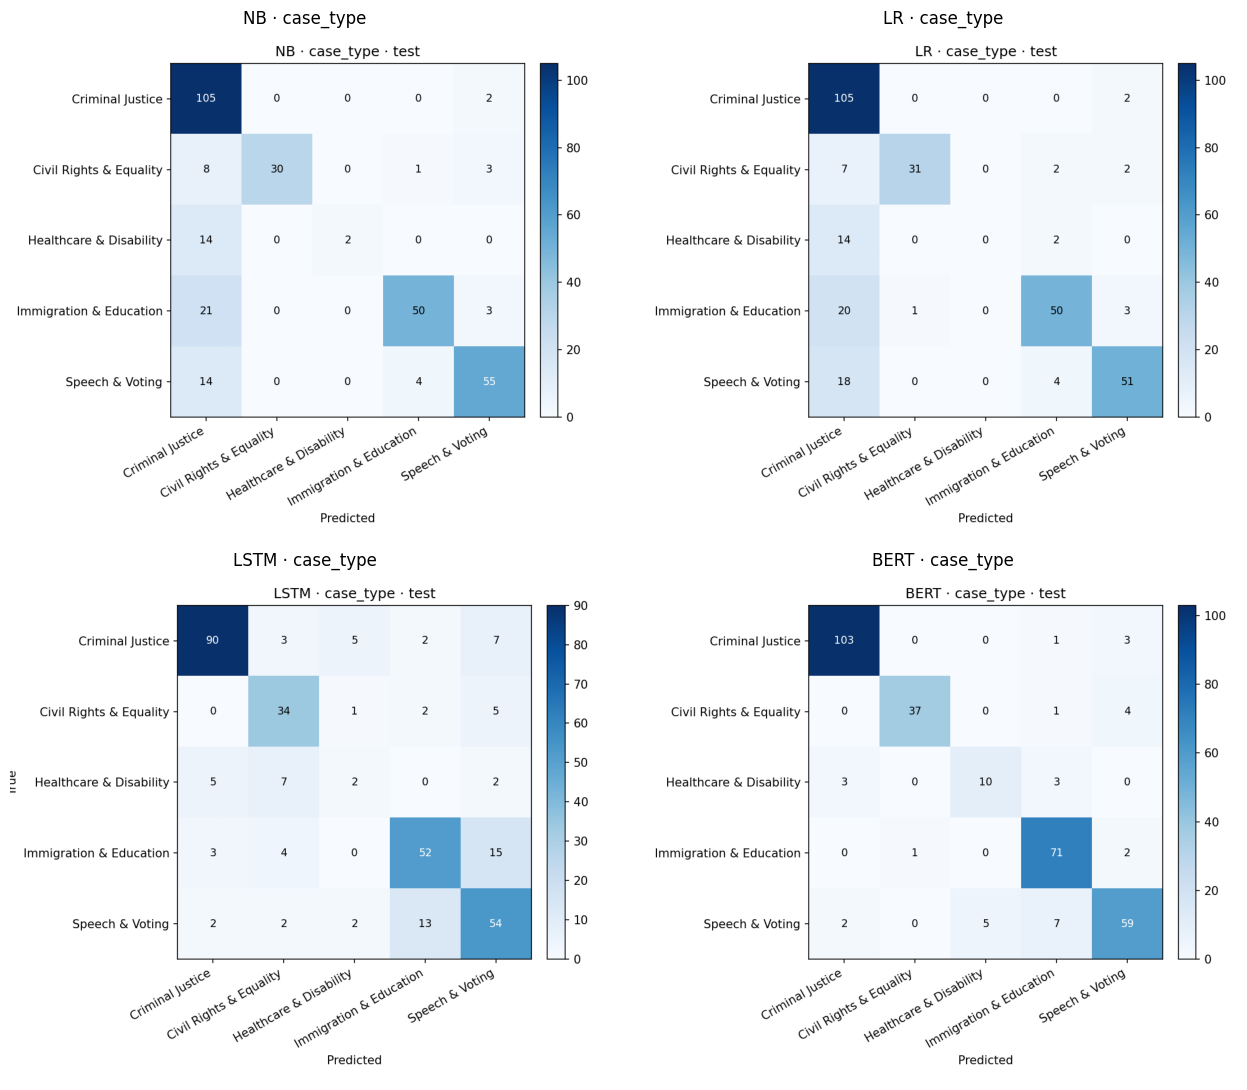

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, model in zip(axes.ravel(), MODELS):
    img_path = RESULTS_DIR / 'confusion_matrices' / f'{model}_{TAG}_test.png'
    if not img_path.exists():
        ax.text(0.5, 0.5, f'{model.upper()}\n(not trained yet)', ha='center', va='center')
        ax.axis('off')
        continue
    img = plt.imread(img_path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'{model.upper()} · case_type')
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'case_type_confusion_grid.png', dpi=120)
plt.show()

## 5. Training curves (LSTM + BERT)

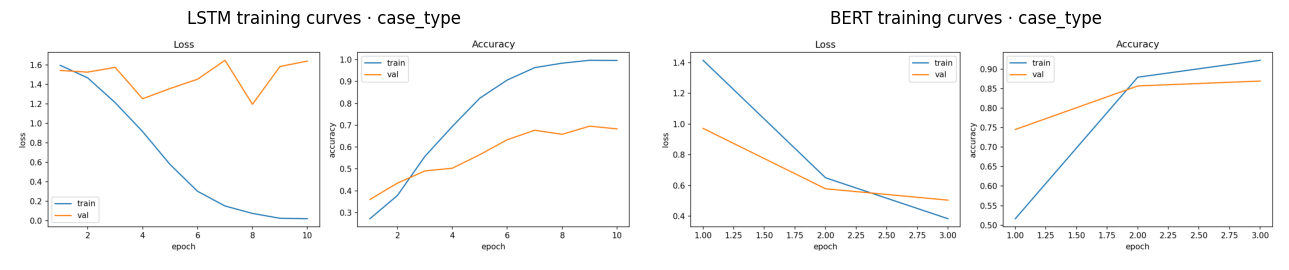

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, model in zip(axes, ['lstm', 'bert']):
    img_path = RESULTS_DIR / 'training_curves' / f'{model}_{TAG}.png'
    if not img_path.exists():
        ax.text(0.5, 0.5, f'{model.upper()}\n(not trained yet)', ha='center', va='center')
        ax.axis('off')
        continue
    img = plt.imread(img_path)
    ax.imshow(img); ax.axis('off')
    ax.set_title(f'{model.upper()} training curves · case_type')
fig.tight_layout()
plt.show()

## 6. Slide-ready summary text

Auto-generated bullet points for slide 9.

In [7]:
if test['f1_macro'].notna().any():
    best = test['f1_macro'].dropna().idxmax()
    print(f'- Best model: **{best.upper()}** (macro F1 = {test.loc[best, "f1_macro"]:.3f})')
    print(f'- Baseline gap: ΔF1 (best − NB) = {(test.loc[best, "f1_macro"] - test.loc["nb", "f1_macro"]):+.3f}')
    if not per_class.empty:
        support_by_class = per_class.groupby('class')['support'].first().sort_values()
        smallest_name = support_by_class.index[0]
        print(f'- Smallest class: `{smallest_name}` (n={int(support_by_class.iloc[0])}); per-model F1:')
        f1_for_smallest = per_class[per_class['class'] == smallest_name].set_index('model')['f1']
        for m, f in f1_for_smallest.reindex(MODELS).items():
            print(f'    · {m}: {f:.3f}' if not pd.isna(f) else f'    · {m}: (no data)')
else:
    print('Train deep models first (notebook 06) to populate this section.')

- Best model: **BERT** (macro F1 = 0.854)
- Baseline gap: ΔF1 (best − NB) = +0.170
- Smallest class: `Healthcare & Disability` (n=16); per-model F1:
    · nb: 0.222
    · lr: 0.000
    · lstm: 0.154
    · bert: 0.645
